<a href="https://colab.research.google.com/github/SamiraKheradmand/IASC-ASCE-Transformer-SHM/blob/main/notebooks/02_split_methods/chronological/D16_Chronological_transformer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [226]:
import os
import scipy.io as sio
from scipy.io.matlab._mio5_params import mat_struct
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import train_test_split

from pathlib import Path
import re
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

In [227]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [228]:
!ls "/content/drive/My Drive/ASCE_IASC"

figures					random_window_split_seed42.csv
MAT_data				Results
processed_zero_mean			txt_all_15_sensors
random_block_assignment_45s_seed42.csv	txt_selected_sensors


In [229]:
from pathlib import Path

import numpy as np
import scipy.io as sio


# مسیر فایل‌ها
DATA_DIR = Path("/content/drive/MyDrive/ASCE_IASC/MAT_data")

# فقط 15 سنسور واقعی سازه
CHANNELS = [f"DA{i:02d}" for i in range(1, 17)]

# پیدا کردن فایل‌های 9 حالت سازه
mat_files = sorted(DATA_DIR.glob("shm*.mat"))

print("Folder exists:", DATA_DIR.exists())
print("Number of files:", len(mat_files))
print("Number of channels:", len(CHANNELS))


def load_ambient_file(file_path):
    """
    خواندن یک فایل Ambient از داده‌های IASC-ASCE
    """

    mat = sio.loadmat(file_path,squeeze_me=True,struct_as_record=False)

    dasy = mat["dasy"]
    dasy_dscr = mat["dasy_dscr"]
    fs = float(mat["fsdasy"])

    signals = []
    descriptions = []

    for i, channel in enumerate(CHANNELS, start=1):

        signal = np.asarray(getattr(dasy, channel)).reshape(-1)

        description_name = f"DAdscr{i:02d}"
        description = getattr(dasy_dscr, description_name)

        signals.append(signal)
        descriptions.append(description)

    # شکل خروجی:
    # (تعداد نمونه‌های زمانی، تعداد سنسورها)
    X_raw = np.column_stack(signals)

    return X_raw, fs, descriptions

Folder exists: True
Number of files: 9
Number of channels: 16


In [230]:
all_cases = {}

for file_path in mat_files:

    case_name = file_path.stem
    case_number = int(case_name[3:5])

    X_raw, fs, descriptions = load_ambient_file(file_path)

    all_cases[case_name] = {
        "X_raw": X_raw,
        "fs": fs,
        "channels": CHANNELS.copy(),
        "descriptions": descriptions,
        "case_number": case_number,
        "label": case_number - 1,
        "file_path": file_path
    }

    print(
        f"{case_name} | "
        f"shape: {X_raw.shape} | "
        f"fs: {fs} Hz | "
        f"label: {case_number - 1}"

    )
print( f"description: {pd.DataFrame(descriptions)}")

shm01a | shape: (60000, 16) | fs: 200.0 Hz | label: 0
shm02a | shape: (60000, 16) | fs: 200.0 Hz | label: 1
shm03a | shape: (60000, 16) | fs: 200.0 Hz | label: 2
shm04a | shape: (60000, 16) | fs: 200.0 Hz | label: 3
shm05a | shape: (60000, 16) | fs: 200.0 Hz | label: 4
shm06a | shape: (45568, 16) | fs: 200.0 Hz | label: 5
shm07a | shape: (180000, 16) | fs: 200.0 Hz | label: 6
shm08a | shape: (180000, 16) | fs: 200.0 Hz | label: 7
shm09a | shape: (180000, 16) | fs: 200.0 Hz | label: 8
description:                                                     0
0        Base West side - EPI sensor X direction (N+)
1           Base Center - EPI sensor Y direction (W+)
2        Base East side - EPI sensor X direction (N+)
3         1st Floor - N/S EPI Sensor at West end (N+)
4           1st Floor - E/W FBA Sensor at Center (W+)
5         1st Floor - N/S FBA Sensor at East end (N+)
6         2nd Floor - N/S FBA Sensor at West end (N+)
7           2nd Floor - E/W EPI Sensor at Center (W+)
8         2n

In [231]:
print(all_cases["shm01a"]["X_raw"].shape)
print(all_cases["shm01a"]["channels"])


(60000, 16)
['DA01', 'DA02', 'DA03', 'DA04', 'DA05', 'DA06', 'DA07', 'DA08', 'DA09', 'DA10', 'DA11', 'DA12', 'DA13', 'DA14', 'DA15', 'DA16']


In [232]:
# ============================================================
# Step 2: Chronological split and Butterworth high-pass filter
# Filter is applied separately to Train, Validation and Test
# ============================================================

import pandas as pd
from scipy.signal import butter, sosfiltfilt


# ----------------------------
# Split settings
# ----------------------------
TRAIN_RATIO = 0.60
VAL_RATIO = 0.20

GAP_SEC = 0
EDGE_SEC = 2


# ----------------------------
# High-pass filter settings
# ----------------------------
CUTOFF = 0.1
ORDER = 2


def highpass_filter(X, fs):

    """
    Apply a Butterworth high-pass filter to all sensor channels.
    X shape:(samples, sensors)
    """

    sos = butter(N=ORDER, Wn=CUTOFF,btype="highpass",fs=fs,output="sos")
    X_filtered = sosfiltfilt(sos,X,axis=0)

    return X_filtered

In [233]:
train_data = {}
val_data = {}
test_data = {}

split_report = []

for case_name in sorted(all_cases.keys()):

    # Raw data
    X = all_cases[case_name]["X_raw"]
    fs = all_cases[case_name]["fs"]

    n_samples = len(X)

    gap_size = int(GAP_SEC * fs)
    edge_size = int(EDGE_SEC * fs)

    # ----------------------------
    # Chronological split boundaries
    # ----------------------------
    train_end = int(TRAIN_RATIO * n_samples)

    val_start = train_end + gap_size
    val_end = val_start + int(VAL_RATIO * n_samples)

    test_start = val_end + gap_size

    if test_start >= n_samples:
        raise ValueError(f"{case_name}: signal is too short for this gap.")

    # ----------------------------
    # Split raw signal
    # ----------------------------
    X_train_raw = X[:train_end]
    X_val_raw = X[val_start:val_end]
    X_test_raw = X[test_start:]

    # Check split lengths
    if min(len(X_train_raw), len(X_val_raw), len(X_test_raw)) <= 2 * edge_size:
        raise ValueError(f"{case_name}: EDGE_SEC is too large.")

    # ----------------------------
    # Filter each split separately
    # ----------------------------
    X_train_filtered = highpass_filter(X_train_raw, fs)
    X_val_filtered  = highpass_filter(X_val_raw, fs)
    X_test_filtered = highpass_filter(X_test_raw, fs)

    # ----------------------------
    # Remove filter edges
    # ----------------------------
    X_train_filtered = X_train_filtered[edge_size:-edge_size]
    X_val_filtered  = X_val_filtered[edge_size:-edge_size]
    X_test_filtered = X_test_filtered[edge_size:-edge_size]

    # ----------------------------
    # Save filtered data
    # ----------------------------
    train_data[case_name] = X_train_filtered
    val_data[case_name] = X_val_filtered
    test_data[case_name] = X_test_filtered

    split_report.append({
        "case": case_name,
        "total_samples": n_samples,

        "train_samples_filtered": len(X_train_filtered),
        "val_samples_filtered": len(X_val_filtered),
        "test_samples_filtered":len(X_test_filtered),
        "train_duration_sec":len(X_train_filtered) / fs,
        "val_duration_sec":len(X_val_filtered) / fs,
        "test_duration_sec":len(X_test_filtered) / fs
    })


split_report_df = pd.DataFrame(split_report)

display(split_report_df)

,case,total_samples,train_samples_filtered,val_samples_filtered,test_samples_filtered,train_duration_sec,val_duration_sec,test_duration_sec
0,shm01a,60000,35200,11200,11200,176.0,56.000,56.000
1,shm02a,60000,35200,11200,11200,176.0,56.000,56.000
2,shm03a,60000,35200,11200,11200,176.0,56.000,56.000
3,shm04a,60000,35200,11200,11200,176.0,56.000,56.000
4,shm05a,60000,35200,11200,11200,176.0,56.000,56.000
5,shm06a,45568,26540,8313,8315,132.7,41.565,41.575
6,shm07a,180000,107200,35200,35200,536.0,176.000,176.000
7,shm08a,180000,107200,35200,35200,536.0,176.000,176.000
8,shm09a,180000,107200,35200,35200,536.0,176.000,176.000


In [234]:
for case_name in sorted(train_data.keys()):

    print(f"{case_name} | "
          f"Train: {train_data[case_name].shape} | "
          f"Validation: {val_data[case_name].shape} | "
          f"Test: {test_data[case_name].shape}" )

shm01a | Train: (35200, 16) | Validation: (11200, 16) | Test: (11200, 16)
shm02a | Train: (35200, 16) | Validation: (11200, 16) | Test: (11200, 16)
shm03a | Train: (35200, 16) | Validation: (11200, 16) | Test: (11200, 16)
shm04a | Train: (35200, 16) | Validation: (11200, 16) | Test: (11200, 16)
shm05a | Train: (35200, 16) | Validation: (11200, 16) | Test: (11200, 16)
shm06a | Train: (26540, 16) | Validation: (8313, 16) | Test: (8315, 16)
shm07a | Train: (107200, 16) | Validation: (35200, 16) | Test: (35200, 16)
shm08a | Train: (107200, 16) | Validation: (35200, 16) | Test: (35200, 16)
shm09a | Train: (107200, 16) | Validation: (35200, 16) | Test: (35200, 16)


In [235]:
filter_check = []

for case_name in sorted(all_cases.keys()):

    raw_train_end = int(TRAIN_RATIO * len(all_cases[case_name]["X_raw"]))
    X_train_raw = all_cases[case_name]["X_raw"][:raw_train_end]
    X_train_filtered = train_data[case_name]

    filter_check.append({
        "case": case_name,
        "mean_abs_raw": np.mean(np.abs(np.mean(X_train_raw, axis=0))),
        "mean_abs_filtered": np.mean(np.abs(np.mean(X_train_filtered,axis=0)))
    })

filter_check_df = pd.DataFrame(filter_check)
display(filter_check_df)

,case,mean_abs_raw,mean_abs_filtered
0,shm01a,0.001458,1.335379e-06
1,shm02a,0.001555,3.159473e-07
2,shm03a,0.000949,3.466417e-07
3,shm04a,0.001423,4.443785e-07
4,shm05a,0.001474,2.066132e-06
5,shm06a,0.001171,2.194902e-06
6,shm07a,0.001088,1.873144e-07
7,shm08a,0.001384,2.837958e-07
8,shm09a,0.001152,1.672797e-07


In [236]:
# ============================================================
# Step 3: Select sensor channels
# ============================================================

# selected_sensor_indices = [8, 11, 13, 14]  # DA09, DA12, DA14, DA15
selected_sensor_indices = [15]
# selected_sensor_indices = [3,4,5,6,7,8,9,10,11,12,13,14]

selected_sensor_names = [CHANNELS[i] for i in selected_sensor_indices]

train_selected = {}
val_selected = {}
test_selected = {}

for case_name in train_data.keys():
    train_selected[case_name] = train_data[case_name][:, selected_sensor_indices]
    val_selected[case_name]   = val_data[case_name][:, selected_sensor_indices]
    test_selected[case_name]  = test_data[case_name][:, selected_sensor_indices]

print("Selected sensors:", selected_sensor_names)

for case_name in sorted(train_selected.keys()):
    print(
        f"Case {case_name}: "
        f"train={train_selected[case_name].shape}, "
        f"val={val_selected[case_name].shape}, "
        f"test={test_selected[case_name].shape}"
    )

Selected sensors: ['DA16']
Case shm01a: train=(35200, 1), val=(11200, 1), test=(11200, 1)
Case shm02a: train=(35200, 1), val=(11200, 1), test=(11200, 1)
Case shm03a: train=(35200, 1), val=(11200, 1), test=(11200, 1)
Case shm04a: train=(35200, 1), val=(11200, 1), test=(11200, 1)
Case shm05a: train=(35200, 1), val=(11200, 1), test=(11200, 1)
Case shm06a: train=(26540, 1), val=(8313, 1), test=(8315, 1)
Case shm07a: train=(107200, 1), val=(35200, 1), test=(35200, 1)
Case shm08a: train=(107200, 1), val=(35200, 1), test=(35200, 1)
Case shm09a: train=(107200, 1), val=(35200, 1), test=(35200, 1)


In [237]:
# ============================================================
# Step 4: Global train-based normalization
# One mean and standard deviation for each selected sensor
# ============================================================

EPS = 1e-8
train_concat = np.concatenate(
    [train_selected[case_name] for case_name in sorted(train_selected.keys())],axis=0)


print("Combined Train shape:", train_concat.shape)
train_mean = train_concat.mean(axis=0,keepdims=True,dtype=np.float64)
train_std = train_concat.std(axis=0,keepdims=True,dtype=np.float64)


# Prevent division by zero
train_std_safe = np.where(train_std < EPS,1.0,train_std)


print("Train mean shape:", train_mean.shape)
print("Train std shape:", train_std_safe.shape)

Combined Train shape: (524140, 1)
Train mean shape: (1, 1)
Train std shape: (1, 1)


In [238]:
train_norm = {}
val_norm = {}
test_norm = {}


for case_name in sorted(train_selected.keys()):

    train_norm[case_name] = ((train_selected[case_name] - train_mean)/ train_std_safe).astype(np.float32)
    val_norm[case_name]   = ((val_selected[case_name] - train_mean)/ train_std_safe).astype(np.float32)
    test_norm[case_name]  = ((test_selected[case_name] - train_mean)/ train_std_safe).astype(np.float32)


print("Normalization completed.")

Normalization completed.


In [239]:
train_norm_concat = np.concatenate(
    [ train_norm[case_name] for case_name in sorted(train_norm.keys())],axis=0)

normalized_train_mean = train_norm_concat.mean(axis=0)
normalized_train_std = train_norm_concat.std(axis=0)

print("Train mean after normalization:")
print(np.round(normalized_train_mean,5))

print("\nTrain std after normalization:")
print(np.round(normalized_train_std,5))

Train mean after normalization:
[0.]

Train std after normalization:
[1.]


In [240]:
# ============================================================
# Step 5: Create non-overlapping time windows
# ============================================================

WINDOW_SIZE = 512
STEP_SIZE = 512

FS_DASY = 200

print("Window size:", WINDOW_SIZE, "samples")
print("Window duration:", WINDOW_SIZE / FS_DASY, "seconds")
print("Step size:", STEP_SIZE, "samples")
print("Step duration:", STEP_SIZE / FS_DASY, "seconds")

Window size: 512 samples
Window duration: 2.56 seconds
Step size: 512 samples
Step duration: 2.56 seconds


In [241]:
def make_windows(split_data):

    all_windows = []
    all_labels = []
    meta_rows = []

    for case_name in sorted(split_data.keys()):

        X = split_data[case_name]

        n_samples = len(X)

        # shm01a -> scenario 1 -> label 0
        scenario_number = int(case_name[3:5])
        label = scenario_number - 1

        window_number = 0

        for start in range(0, n_samples - WINDOW_SIZE + 1,STEP_SIZE):

            end = start + WINDOW_SIZE

            window = X[start:end, :]

            all_windows.append(window)
            all_labels.append(label)

            meta_rows.append({
                "case": case_name,
                "scenario": scenario_number,
                "label": label,
                "window": window_number,
                "start_sample": start,
                "end_sample": end
            })

            window_number += 1

    if len(all_windows) == 0:
        raise ValueError("No windows were created.")

    X_windows = np.stack(all_windows,axis=0).astype(np.float32)

    y_labels = np.array(all_labels,dtype=np.int64)

    meta_df = pd.DataFrame(meta_rows)

    return X_windows, y_labels, meta_df

In [242]:
X_train, y_train, train_meta_df = make_windows(train_norm)

X_val, y_val, val_meta_df = make_windows(val_norm)

X_test, y_test, test_meta_df = make_windows(test_norm)

In [243]:
print("Window shapes:")
print("X_train:", X_train.shape)
print("X_val:  ", X_val.shape)
print("X_test: ", X_test.shape)

print("\nLabel shapes:")
print("y_train:", y_train.shape)
print("y_val:  ", y_val.shape)
print("y_test: ", y_test.shape)

Window shapes:
X_train: (1018, 512, 1)
X_val:   (325, 512, 1)
X_test:  (325, 512, 1)

Label shapes:
y_train: (1018,)
y_val:   (325,)
y_test:  (325,)


In [244]:
print("\nTrain class counts:")
print(pd.Series(y_train).value_counts().sort_index())

print("\nValidation class counts:")
print(pd.Series(y_val).value_counts().sort_index())

print("\nTest class counts:")
print(pd.Series(y_test).value_counts().sort_index())


Train class counts:
0     68
1     68
2     68
3     68
4     68
5     51
6    209
7    209
8    209
Name: count, dtype: int64

Validation class counts:
0    21
1    21
2    21
3    21
4    21
5    16
6    68
7    68
8    68
Name: count, dtype: int64

Test class counts:
0    21
1    21
2    21
3    21
4    21
5    16
6    68
7    68
8    68
Name: count, dtype: int64


In [245]:
print("Channels:", CHANNELS)
print("Number of channels:", len(CHANNELS))

print("\nDA16 descriptions:")
for case_name in sorted(all_cases.keys()):
    print(
        case_name,
        all_cases[case_name]["descriptions"][15]
    )

Channels: ['DA01', 'DA02', 'DA03', 'DA04', 'DA05', 'DA06', 'DA07', 'DA08', 'DA09', 'DA10', 'DA11', 'DA12', 'DA13', 'DA14', 'DA15', 'DA16']
Number of channels: 16

DA16 descriptions:
shm01a Ambient Noise in System  - Unfiltered (Disconnected)
shm02a Ambient Noise in System  - Unfiltered (Disconnected)
shm03a Ambient Noise in System  - Unfiltered (Disconnected)
shm04a Ambient Noise in System  - Unfiltered (Disconnected)
shm05a Ambient Noise in System  - Unfiltered (Disconnected)
shm06a Ambient Noise in System  - Unfiltered (Disconnected)
shm07a Ambient Noise in System  - Unfiltered (Disconnected)
shm08a Ambient Noise in System  - Unfiltered (Disconnected)
shm09a Ambient Noise in System  - Unfiltered (Disconnected)


In [284]:
import numpy as np
import torch

from torch.utils.data import TensorDataset, DataLoader


# ----------------------------
# بررسی داده‌ها قبل از Tensor
# ----------------------------
print("X_train shape:", X_train.shape)
print("X_val shape:  ", X_val.shape)
print("X_test shape: ", X_test.shape)

print("y_train shape:", y_train.shape)
print("y_val shape:  ", y_val.shape)
print("y_test shape: ", y_test.shape)


# تعداد داده و برچسب باید برابر باشد
assert len(X_train) == len(y_train)
assert len(X_val) == len(y_val)
assert len(X_test) == len(y_test)

# بررسی NaN و Inf
assert np.isfinite(X_train).all(), "X_train contains NaN or Inf."
assert np.isfinite(X_val).all(), "X_val contains NaN or Inf."
assert np.isfinite(X_test).all(), "X_test contains NaN or Inf."

print("Data check completed.")

X_train shape: (1018, 512, 1)
X_val shape:   (325, 512, 1)
X_test shape:  (325, 512, 1)
y_train shape: (1018,)
y_val shape:   (325,)
y_test shape:  (325,)
Data check completed.


In [285]:
# ============================================================
# DA16 diagnostic - Remove window-level amplitude signature
# ============================================================

def standardize_each_window(X):

    X_out = X.copy()

    window_mean = X_out.mean(
        axis=1,
        keepdims=True
    )

    window_std = X_out.std(
        axis=1,
        keepdims=True
    )

    X_out = (
        X_out - window_mean
    ) / (window_std + 1e-8)

    return X_out


X_train_window_std = standardize_each_window(X_train)
X_val_window_std = standardize_each_window(X_val)

print("Shapes:")
print("Train:", X_train_window_std.shape)
print("Val:  ", X_val_window_std.shape)

print("\nMedian window STD after standardization:")
print(
    "Train:",
    np.median(
        X_train_window_std.std(axis=1)
    )
)

print(
    "Val:",
    np.median(
        X_val_window_std.std(axis=1)
    )
)

Shapes:
Train: (1018, 512, 1)
Val:   (325, 512, 1)

Median window STD after standardization:
Train: 1.0
Val: 1.0


In [286]:
for scenario in range(9):

    mask = y_val == scenario

    rms = np.sqrt(
        np.mean(
            X_val_window_std[mask, :, 0]**2,
            axis=1
        )
    )

    print(
        scenario,
        "median RMS:",
        np.median(rms)
    )

0 median RMS: 1.0
1 median RMS: 1.0
2 median RMS: 1.0
3 median RMS: 1.0
4 median RMS: 1.0
5 median RMS: 1.0
6 median RMS: 1.0
7 median RMS: 1.0
8 median RMS: 1.0


In [288]:
# ============================================================
# Step 6: Convert arrays to PyTorch tensors
# ============================================================

import random
import numpy as np
import torch

from torch.utils.data import TensorDataset, DataLoader


# ----------------------------
# Reproducibility
# ----------------------------
SPLIT_SEED = None
MODEL_SEED = 42

def set_seed(seed):

    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)

    # Reproducibility for CUDA
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

    # Warn if a nondeterministic operation is used
    torch.use_deterministic_algorithms(True,warn_only=True)

set_seed(MODEL_SEED)

# Inputs must be float32
X_train_tensor = torch.from_numpy(X_train_window_std.astype(np.float32, copy=False))
X_val_tensor = torch.from_numpy(X_val_window_std.astype(np.float32, copy=False))
X_test_tensor = torch.from_numpy(X_test.astype(np.float32, copy=False))


# Labels for CrossEntropyLoss must be int64
y_train_tensor = torch.from_numpy(y_train.astype(np.int64, copy=False))
y_val_tensor = torch.from_numpy(y_val.astype(np.int64, copy=False))
y_test_tensor = torch.from_numpy(y_test.astype(np.int64, copy=False))


print("\nTensor shapes:")
print("X_train_tensor:", X_train_tensor.shape)
print("y_train_tensor:", y_train_tensor.shape)

print("X_val_tensor:", X_val_tensor.shape)
print("y_val_tensor:", y_val_tensor.shape)

print("X_test_tensor:", X_test_tensor.shape)
print("y_test_tensor:", y_test_tensor.shape)


Tensor shapes:
X_train_tensor: torch.Size([1018, 512, 1])
y_train_tensor: torch.Size([1018])
X_val_tensor: torch.Size([325, 512, 1])
y_val_tensor: torch.Size([325])
X_test_tensor: torch.Size([325, 512, 1])
y_test_tensor: torch.Size([325])


In [289]:
# ============================================================
# DA16 negative-control checks before training
# ============================================================

print("Selected sensors:", selected_sensor_names)

print("\nWindowed data:")
print("X_train:", X_train.shape)
print("X_val:  ", X_val.shape)
print("X_test: ", X_test.shape)

print("\nTensor data:")
print("X_train_tensor:", X_train_tensor.shape)
print("X_val_tensor:  ", X_val_tensor.shape)

print("\nModel input dimension:")
print("INPUT_DIM =", X_train_tensor.shape[2])

assert selected_sensor_names == ["DA16"]
assert X_train.shape[2] == 1
assert X_val.shape[2] == 1
assert X_train_tensor.shape[2] == 1

print("\nDA16-only input check passed.")

Selected sensors: ['DA16']

Windowed data:
X_train: (1018, 512, 1)
X_val:   (325, 512, 1)
X_test:  (325, 512, 1)

Tensor data:
X_train_tensor: torch.Size([1018, 512, 1])
X_val_tensor:   torch.Size([325, 512, 1])

Model input dimension:
INPUT_DIM = 1

DA16-only input check passed.


In [290]:
# ============================================================
# Create Dataset and DataLoader
# ============================================================

train_dataset = TensorDataset(X_train_tensor,y_train_tensor)
val_dataset   = TensorDataset(X_val_tensor,y_val_tensor)
test_dataset  = TensorDataset(X_test_tensor,y_test_tensor)

BATCH_SIZE = 64

# برای تکرارپذیری Shuffle داده‌های Train
loader_generator = torch.Generator()
loader_generator.manual_seed(MODEL_SEED)


train_loader = DataLoader(train_dataset,batch_size=BATCH_SIZE,shuffle=True,generator=loader_generator)
val_loader   = DataLoader(val_dataset,batch_size=BATCH_SIZE,shuffle=False)
test_loader  = DataLoader(test_dataset,batch_size=BATCH_SIZE,shuffle=False)

In [250]:
print("Number of train samples:", len(train_dataset))
print("Number of val samples:  ", len(val_dataset))
print("Number of test samples: ", len(test_dataset))

print("\nNumber of train batches:", len(train_loader))
print("Number of val batches:  ", len(val_loader))
print("Number of test batches: ", len(test_loader))


X_batch, y_batch = next(iter(train_loader))

print("\nOne train batch:")
print("X_batch shape:", X_batch.shape)
print("y_batch shape:", y_batch.shape)
print("First 10 labels:", y_batch[:10])

Number of train samples: 1018
Number of val samples:   325
Number of test samples:  325

Number of train batches: 16
Number of val batches:   6
Number of test batches:  6

One train batch:
X_batch shape: torch.Size([64, 512, 1])
y_batch shape: torch.Size([64])
First 10 labels: tensor([4, 8, 8, 6, 6, 7, 2, 1, 8, 8])


In [291]:
# ============================================================
# Step 7: Define raw time-series Transformer
# Input shape: (batch, time, sensors)
# ============================================================

import torch.nn as nn
from sklearn.metrics import accuracy_score, f1_score

# ----------------------------
# Device
# ----------------------------
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)


# ----------------------------
# Learnable positional encoding
# ----------------------------
class LearnablePositionalEncoding(nn.Module):

    def __init__(self, seq_len, d_model):
        super().__init__()
        self.position = nn.Parameter(torch.zeros(1, seq_len, d_model))
        nn.init.trunc_normal_(self.position,std=0.02)

    def forward(self, x):
        seq_len = x.shape[1]
        return x + self.position[:, :seq_len, :]

Device: cuda


In [292]:
# ============================================================
# Step 7: Define raw time-series Transformer
# Input shape: (batch, time, sensors)
# ============================================================

import torch.nn as nn

# --- Added these definitions to ensure the model parameters are defined ---
NUM_CLASSES = 9
SEQ_LEN = WINDOW_SIZE
INPUT_DIM = X_train_tensor.shape[2]
D_MODEL = 64
NUM_HEADS = 8
NUM_LAYERS = 2
DIM_FEEDFORWARD = 64
DROPOUT = 0.1
# --- End of added definitions ---

class TransformerTimeSeriesClassifier(nn.Module):
    def __init__(
        self,
        input_dim,
        seq_len,
        num_classes,
        d_model=64,
        num_heads=8,
        num_layers=2,
        dim_feedforward=64,
        dropout=0.10
    ):
        super().__init__()

        self.seq_len = seq_len
        self.d_model = d_model

        self.input_projection = nn.Linear(input_dim, d_model)
        self.pos_embedding = nn.Parameter(torch.zeros(1, seq_len, d_model))

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=num_heads,
            dim_feedforward=dim_feedforward,
            dropout=dropout,
            activation="relu",
            batch_first=True,
            norm_first=True
        )

        self.transformer_encoder = nn.TransformerEncoder(encoder_layer,num_layers=num_layers)
        self.final_norm = nn.LayerNorm(d_model)
        self.classifier = nn.Linear(d_model,num_classes)
        self._init_weights()

    def _init_weights(self):
        nn.init.normal_(self.pos_embedding, mean=0.0, std=0.02)

    def forward(self, x):
        # x shape: (batch, time, channels)

        x = self.input_projection(x)
        x = x + self.pos_embedding[:, :x.size(1), :]
        x = self.transformer_encoder(x)
        x = self.final_norm(x)
        # Mean pooling over time
        x = x.mean(dim=1)
        logits = self.classifier(x)
        return logits



In [293]:
set_seed(MODEL_SEED)
model = TransformerTimeSeriesClassifier(
    input_dim=INPUT_DIM,
    seq_len=SEQ_LEN,
    num_classes=NUM_CLASSES,
    d_model=D_MODEL,
    num_heads=NUM_HEADS,
    num_layers=NUM_LAYERS,
    dim_feedforward=DIM_FEEDFORWARD,
    dropout=DROPOUT
).to(device)

print(model)

# ----------------------------
# Count trainable parameters
# ----------------------------
def count_trainable_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

print("\nTrainable parameters:", count_trainable_parameters(model))


# ----------------------------
# Check one forward pass
# ----------------------------
for xb, yb in train_loader:
    xb = xb.to(device)

    logits = model(xb)

    print("\nInput batch shape:", xb.shape)
    print("Output logits shape:", logits.shape)

    break

TransformerTimeSeriesClassifier(
  (input_projection): Linear(in_features=1, out_features=64, bias=True)
  (transformer_encoder): TransformerEncoder(
    (layers): ModuleList(
      (0-1): 2 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=64, out_features=64, bias=True)
        )
        (linear1): Linear(in_features=64, out_features=64, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (linear2): Linear(in_features=64, out_features=64, bias=True)
        (norm1): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.1, inplace=False)
        (dropout2): Dropout(p=0.1, inplace=False)
      )
    )
  )
  (final_norm): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
  (classifier): Linear(in_features=64, out_features=9, bias=True)
)

Trainable parameters: 84041

Input batch shape: 

/tmp/ipykernel_3153/3525986821.py:49: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.transformer_encoder = nn.TransformerEncoder(encoder_layer,num_layers=num_layers)


In [294]:
# ============================================================
# Step 8: Loss function and optimizer
# ============================================================

class_counts = torch.bincount(y_train_tensor, minlength=NUM_CLASSES).float()
if torch.any(class_counts == 0):
    raise ValueError("At least one class has no training samples.")

class_weights = (len(y_train_tensor) / (NUM_CLASSES * class_counts))
class_weights = class_weights.to(device)

print("Class counts and weights:")

for class_id in range(NUM_CLASSES):

    print(
        f"Scenario {class_id + 1} | "
        f"count: {int(class_counts[class_id])} | "
        f"weight: {class_weights[class_id].item():.4f}"
    )

Class counts and weights:
Scenario 1 | count: 68 | weight: 1.6634
Scenario 2 | count: 68 | weight: 1.6634
Scenario 3 | count: 68 | weight: 1.6634
Scenario 4 | count: 68 | weight: 1.6634
Scenario 5 | count: 68 | weight: 1.6634
Scenario 6 | count: 51 | weight: 2.2179
Scenario 7 | count: 209 | weight: 0.5412
Scenario 8 | count: 209 | weight: 0.5412
Scenario 9 | count: 209 | weight: 0.5412


In [295]:
LEARNING_RATE = 2e-4
WEIGHT_DECAY = 1e-4
criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = torch.optim.AdamW(model.parameters(),lr=LEARNING_RATE,weight_decay=WEIGHT_DECAY)

print("Loss function:", criterion)
print("Optimizer:", optimizer.__class__.__name__)
print("Learning rate:", LEARNING_RATE)

Loss function: CrossEntropyLoss()
Optimizer: AdamW
Learning rate: 0.0002


In [296]:
# Reset early stopping
best_val_macro_f1 = -1.0
best_val_loss = float("inf")

best_epoch = 0
best_model_state = None

patience_counter = 0
print("New experiment started")
print("Model_Seed:", MODEL_SEED)
print("Heads:", NUM_HEADS)
print("Dropout:", DROPOUT)

New experiment started
Model_Seed: 42
Heads: 8
Dropout: 0.1


In [297]:
from sklearn.metrics import accuracy_score, f1_score
import copy
import torch

NUM_EPOCHS = 100
PATIENCE = 20
GRAD_CLIP = 1.0
MIN_DELTA = 1e-4

LABELS_ORDER = np.arange(NUM_CLASSES)

transformer_history = {
    "epoch": [],
    "train_loss": [],
    "train_acc": [],
    "train_macro_f1": [],
    "val_loss": [],
    "val_acc": [],
    "val_macro_f1": [],
}

best_val_macro_f1 = -1.0
best_epoch = 0
best_model_state = None
epochs_without_improvement = 0


def run_one_epoch_transformer(model, data_loader, criterion, optimizer=None, device="cpu"):
    """
    If optimizer is given: training mode
    If optimizer is None: evaluation mode
    """

    is_training = optimizer is not None

    if is_training:
        model.train()
    else:
        model.eval()

    total_loss = 0.0
    all_preds = []
    all_labels = []

    for xb, yb in data_loader:
        xb = xb.to(device)
        yb = yb.to(device)

        if is_training:
            optimizer.zero_grad()

        with torch.set_grad_enabled(is_training):
            logits = model(xb)
            loss = criterion(logits, yb)

            if is_training:
                loss.backward()

                # Gradient clipping helps Transformer training stability
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=GRAD_CLIP)

                optimizer.step()

        total_loss += loss.item() * xb.size(0)
        preds = torch.argmax(logits, dim=1)
        all_preds.append(preds.detach().cpu())
        all_labels.append(yb.detach().cpu())

    avg_loss = total_loss / len(data_loader.dataset)
    all_preds = torch.cat(all_preds).numpy()
    all_labels = torch.cat(all_labels).numpy()
    acc = accuracy_score(all_labels, all_preds)
    macro_f1 = f1_score(
        all_labels,
        all_preds,
        average="macro",
        zero_division=0
    )

    return avg_loss, acc, macro_f1


for epoch in range(1, NUM_EPOCHS + 1):

    train_loss, train_acc, train_macro_f1 = run_one_epoch_transformer(
        model=model,
        data_loader=train_loader,
        criterion=criterion,
        optimizer=optimizer,
        device=device
    )

    val_loss, val_acc, val_macro_f1 = run_one_epoch_transformer(
        model=model,
        data_loader=val_loader,
        criterion=criterion,
        optimizer=None,
        device=device
    )

    transformer_history["epoch"].append(epoch)
    transformer_history["train_loss"].append(train_loss)
    transformer_history["train_acc"].append(train_acc)
    transformer_history["train_macro_f1"].append(train_macro_f1)
    transformer_history["val_loss"].append(val_loss)
    transformer_history["val_acc"].append(val_acc)
    transformer_history["val_macro_f1"].append(val_macro_f1)

    # Save best model based on validation Macro-F1
    if val_macro_f1 > best_val_macro_f1 + MIN_DELTA:
        best_val_macro_f1 = val_macro_f1
        best_epoch = epoch # Assign epoch here
        best_model_state = copy.deepcopy(model.state_dict())
        epochs_without_improvement = 0
    else:
        epochs_without_improvement += 1

    if epoch == 1 or epoch % 5 == 0:
        print(
            f"Epoch {epoch:03d} | "
            f"Train Loss: {train_loss:.4f} | "
            f"Train Acc: {train_acc:.4f} | "
            f"Train Macro-F1: {train_macro_f1:.4f} | "
            f"Val Loss: {val_loss:.4f} | "
            f"Val Acc: {val_acc:.4f} | "
            f"Val Macro-F1: {val_macro_f1:.4f}"
        )

    # Early stopping
    if epochs_without_improvement >= PATIENCE:
        print(f"\nEarly stopping at epoch {epoch}.")
        break



Epoch 001 | Train Loss: 2.2285 | Train Acc: 0.0462 | Train Macro-F1: 0.0203 | Val Loss: 2.1874 | Val Acc: 0.2738 | Val Macro-F1: 0.1348
Epoch 005 | Train Loss: 2.1457 | Train Acc: 0.1356 | Train Macro-F1: 0.1397 | Val Loss: 2.1526 | Val Acc: 0.1292 | Val Macro-F1: 0.1006
Epoch 010 | Train Loss: 1.9539 | Train Acc: 0.2603 | Train Macro-F1: 0.1529 | Val Loss: 1.9475 | Val Acc: 0.3015 | Val Macro-F1: 0.1924
Epoch 015 | Train Loss: 1.8988 | Train Acc: 0.2701 | Train Macro-F1: 0.1965 | Val Loss: 1.9360 | Val Acc: 0.1815 | Val Macro-F1: 0.1520
Epoch 020 | Train Loss: 1.8286 | Train Acc: 0.3330 | Train Macro-F1: 0.2425 | Val Loss: 1.7902 | Val Acc: 0.3631 | Val Macro-F1: 0.2465
Epoch 025 | Train Loss: 1.7346 | Train Acc: 0.3409 | Train Macro-F1: 0.2409 | Val Loss: 1.7427 | Val Acc: 0.3723 | Val Macro-F1: 0.2660
Epoch 030 | Train Loss: 1.6643 | Train Acc: 0.3919 | Train Macro-F1: 0.3089 | Val Loss: 1.8811 | Val Acc: 0.3415 | Val Macro-F1: 0.2765
Epoch 035 | Train Loss: 1.5736 | Train Acc: 0.41

In [298]:
if best_model_state is None:
    raise RuntimeError("No best model was saved.")

model.load_state_dict(best_model_state)

print("\nTraining finished.")
print("Best epoch:",best_epoch)
print("Best validation Macro-F1:",best_val_macro_f1)


Training finished.
Best epoch: 88
Best validation Macro-F1: 0.5386095581497881


              precision    recall  f1-score   support

      shm01a      0.562     0.429     0.486        21
      shm02a      0.913     1.000     0.955        21
      shm03a      0.364     0.762     0.492        21
      shm04a      0.197     0.619     0.299        21
      shm05a      0.244     0.524     0.333        21
      shm06a      0.684     0.812     0.743        16
      shm07a      0.000     0.000     0.000        68
      shm08a      0.862     0.735     0.794        68
      shm09a      0.976     0.603     0.745        68

    accuracy                          0.535       325
   macro avg      0.534     0.609     0.539       325
weighted avg      0.566     0.535     0.524       325



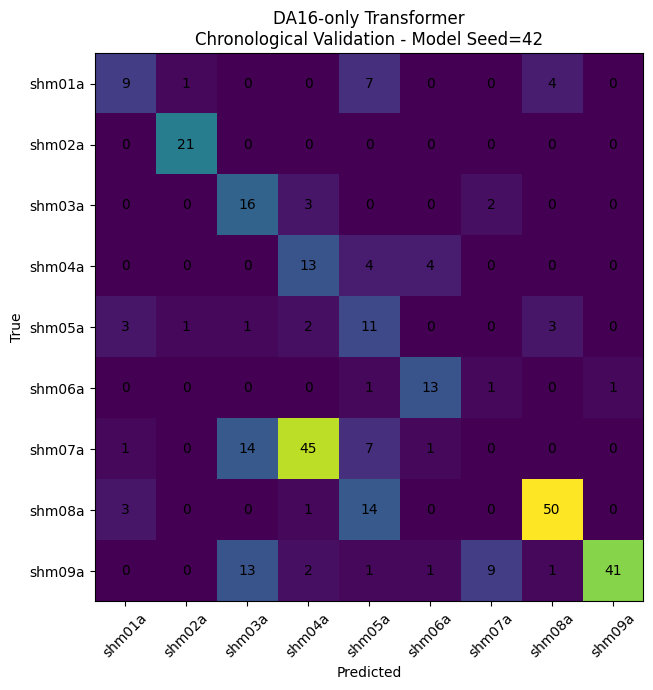

In [299]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix

model.eval()

all_true = []
all_pred = []

with torch.no_grad():

    for xb, yb in val_loader:

        xb = xb.to(device)

        logits = model(xb)
        preds = torch.argmax(logits, dim=1)

        all_true.extend(yb.cpu().numpy())
        all_pred.extend(preds.cpu().numpy())

all_true = np.array(all_true)
all_pred = np.array(all_pred)

class_names = [
    "shm01a", "shm02a", "shm03a",
    "shm04a", "shm05a", "shm06a",
    "shm07a", "shm08a", "shm09a"
]

cm = confusion_matrix(
    all_true,
    all_pred
)

print(
    classification_report(
        all_true,
        all_pred,
        target_names=class_names,
        digits=3
    )
)

plt.figure(figsize=(8, 7))

plt.imshow(cm)

plt.xticks(
    range(9),
    class_names,
    rotation=45
)

plt.yticks(
    range(9),
    class_names
)

plt.xlabel("Predicted")
plt.ylabel("True")
plt.title(
    f"DA16-only Transformer\n"
    f"Chronological Validation - Model Seed={MODEL_SEED}"
)

for i in range(9):
    for j in range(9):
        plt.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center"
        )

plt.tight_layout()
plt.show()

In [300]:
# ============================================================
# DA16 diagnostic - Full log-PSD shape
# Amplitude already removed window-by-window
# ============================================================

from scipy.signal import welch
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score, accuracy_score
import numpy as np

def extract_log_psd(X):

    psd_rows = []

    for i in range(len(X)):

        x = X[i, :, 0]

        f, psd = welch(
            x,
            fs=200.0,
            nperseg=256,
            noverlap=128
        )

        log_psd = np.log10(psd + 1e-20)

        psd_rows.append(log_psd)

    return np.array(psd_rows), f


X_psd_train, freq = extract_log_psd(
    X_train_window_std
)

X_psd_val, _ = extract_log_psd(
    X_val_window_std
)

print("PSD train shape:", X_psd_train.shape)
print("PSD val shape:", X_psd_val.shape)
print("Number of frequency bins:", len(freq))

PSD train shape: (1018, 129)
PSD val shape: (325, 129)
Number of frequency bins: 129


In [301]:
# ============================================================
# Logistic Regression on full log-PSD
# ============================================================

psd_model = Pipeline([
    ("scaler", StandardScaler()),
    ("classifier", LogisticRegression(
        max_iter=5000,
        class_weight="balanced",
        random_state=42
    ))
])

psd_model.fit(
    X_psd_train,
    y_train
)

train_pred = psd_model.predict(X_psd_train)
val_pred = psd_model.predict(X_psd_val)

print("DA16 - Full log-PSD shape")
print("-------------------------")

print(
    "Train Macro-F1:",
    f1_score(y_train, train_pred, average="macro")
)

print(
    "Validation Macro-F1:",
    f1_score(y_val, val_pred, average="macro")
)

print(
    "Validation Accuracy:",
    accuracy_score(y_val, val_pred)
)

DA16 - Full log-PSD shape
-------------------------
Train Macro-F1: 0.7324798005902919
Validation Macro-F1: 0.298979323584185
Validation Accuracy: 0.3723076923076923


In [271]:
# ============================================================
# DA16 diagnostic - Simple window statistics
# ============================================================

from scipy.stats import kurtosis
import pandas as pd
import numpy as np

class_names = [
    "shm01a", "shm02a", "shm03a",
    "shm04a", "shm05a", "shm06a",
    "shm07a", "shm08a", "shm09a"
]

def extract_da16_features(X, y, split_name):

    rows = []

    for i in range(len(X)):

        x = X[i, :, 0]

        rows.append({
            "split": split_name,
            "scenario": class_names[int(y[i])],
            "mean": np.mean(x),
            "rms": np.sqrt(np.mean(x**2)),
            "std": np.std(x),
            "peak_to_peak": np.ptp(x),
            "kurtosis": kurtosis(
                x,
                fisher=False,
                bias=False
            )
        })

    return pd.DataFrame(rows)


train_features = extract_da16_features(
    X_train,
    y_train,
    "Train"
)

val_features = extract_da16_features(
    X_val,
    y_val,
    "Validation"
)

da16_features = pd.concat(
    [train_features, val_features],
    ignore_index=True
)

print("Number of feature rows:", len(da16_features))
display(da16_features.head())

Number of feature rows: 1343


,split,scenario,mean,rms,std,peak_to_peak,kurtosis
0,Train,shm01a,0.045621,0.976696,0.975630,6.131247,3.248312
1,Train,shm01a,-0.053527,1.010230,1.008811,5.900185,3.018798
2,Train,shm01a,0.001056,0.987813,0.987812,6.310802,3.126342
3,Train,shm01a,-0.040292,0.938962,0.938097,5.880377,3.118833
4,Train,shm01a,-0.000111,1.039850,1.039850,6.317611,2.923008


In [272]:
feature_summary = (
    da16_features
    .groupby(["scenario", "split"])[
        ["mean", "rms", "std", "peak_to_peak", "kurtosis"]
    ]
    .median()
    .round(4)
)

display(feature_summary)

mean     rms     std  peak_to_peak  kurtosis
scenario split                                                     
shm01a   Train       0.0005  0.9993  0.9990        6.1001    3.0627
         Validation -0.0082  0.9806  0.9787        6.0961    3.1100
shm02a   Train       0.0019  1.7370  1.7370       14.4980    8.5736
         Validation -0.0029  1.7506  1.7499       14.3069    8.3975
shm03a   Train      -0.0015  0.4312  0.4311        2.9480    3.6064
         Validation -0.0003  0.4247  0.4246        2.9493    3.7746
shm04a   Train      -0.0030  0.4367  0.4361        3.3644    3.8613
         Validation -0.0026  0.4234  0.4223        2.9447    3.4590
shm05a   Train       0.0012  1.0047  1.0033        6.3097    3.0952
         Validation -0.0035  1.0110  1.0107        6.3101    3.2584
shm06a   Train      -0.0057  0.4686  0.4633        3.1650    3.3905
         Validation  0.0013  0.4721  0.4721        3.1625    3.6084
shm07a   Train      -0.0003  0.4204  0.4201        2.9446    3.5360
         Validation -0.0006  0.4215  0.4213        2.9431    3.4974
shm08a   Train      -0.0027  1.1028  1.1013        6.5250    2.9495
         Validation -0.0054  1.1558  1.1558        6.9186    2.9827
shm09a   Train      -0.0016  0.4260  0.4254        2.9451    3.5297
         Validation -0.0022  0.4238  0.4236        2.9453    3.6144

In [273]:
# ============================================================
# DA16 diagnostic - Logistic Regression on simple features
# ============================================================

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score
import pandas as pd

FEATURES = [
    "mean",
    "rms",
    "std",
    "peak_to_peak",
    "kurtosis"
]

X_lr_train = train_features[FEATURES].values
y_lr_train = y_train

X_lr_val = val_features[FEATURES].values
y_lr_val = y_val

lr_model = Pipeline([
    ("scaler", StandardScaler()),
    ("classifier", LogisticRegression(
        max_iter=5000,
        class_weight="balanced",
        random_state=42
    ))
])

lr_model.fit(X_lr_train, y_lr_train)

train_pred = lr_model.predict(X_lr_train)
val_pred = lr_model.predict(X_lr_val)

print("DA16 - 5 simple features")
print("-------------------------")

print(
    "Train Macro-F1:",
    f1_score(y_lr_train, train_pred, average="macro")
)

print(
    "Validation Macro-F1:",
    f1_score(y_lr_val, val_pred, average="macro")
)

print(
    "Validation Accuracy:",
    accuracy_score(y_lr_val, val_pred)
)

DA16 - 5 simple features
-------------------------
Train Macro-F1: 0.4149546941435332
Validation Macro-F1: 0.417600683118208
Validation Accuracy: 0.5076923076923077


In [274]:
# ============================================================
# DA16 diagnostic - Each simple feature separately
# ============================================================

single_feature_results = []

for feature in FEATURES:

    X_train_one = train_features[[feature]].values
    X_val_one = val_features[[feature]].values

    model_one = Pipeline([
        ("scaler", StandardScaler()),
        ("classifier", LogisticRegression(
            max_iter=5000,
            class_weight="balanced",
            random_state=42
        ))
    ])

    model_one.fit(
        X_train_one,
        y_lr_train
    )

    train_pred = model_one.predict(X_train_one)
    val_pred = model_one.predict(X_val_one)

    single_feature_results.append({
        "feature": feature,
        "train_macro_f1": f1_score(
            y_lr_train,
            train_pred,
            average="macro"
        ),
        "validation_macro_f1": f1_score(
            y_lr_val,
            val_pred,
            average="macro"
        ),
        "validation_accuracy": accuracy_score(
            y_lr_val,
            val_pred
        )
    })

single_feature_df = pd.DataFrame(
    single_feature_results
).sort_values(
    "validation_macro_f1",
    ascending=False
)

display(single_feature_df)

,feature,train_macro_f1,validation_macro_f1,validation_accuracy
2,std,0.326306,0.346288,0.452308
1,rms,0.313761,0.338595,0.436923
3,peak_to_peak,0.293419,0.303983,0.473846
4,kurtosis,0.213072,0.203601,0.335385
0,mean,0.058504,0.060477,0.064615


In [275]:
# ============================================================
# DA16 diagnostic - Spectral features
# ============================================================

from scipy.signal import welch
import numpy as np
import pandas as pd

FS = 200.0

def extract_da16_spectral_features(X, y, split_name):

    rows = []

    for i in range(len(X)):

        x = X[i, :, 0]

        f, psd = welch(
            x,
            fs=FS,
            nperseg=256,
            noverlap=128
        )

        eps = 1e-20

        total_energy = np.trapz(psd, f)

        spectral_flatness = (
            np.exp(np.mean(np.log(psd + eps)))
            / np.mean(psd + eps)
        )

        spectral_centroid = (
            np.sum(f * psd)
            / np.sum(psd + eps)
        )

        def band_energy(f1, f2):
            mask = (f >= f1) & (f < f2)
            return np.trapz(psd[mask], f[mask])

        rows.append({
            "split": split_name,
            "scenario": int(y[i]),

            "total_psd_energy": total_energy,
            "spectral_flatness": spectral_flatness,
            "spectral_centroid": spectral_centroid,

            "energy_0_5": band_energy(0.1, 5),
            "energy_5_10": band_energy(5, 10),
            "energy_10_20": band_energy(10, 20),
            "energy_20_40": band_energy(20, 40),
            "energy_40_80": band_energy(40, 80),
        })

    return pd.DataFrame(rows)


train_spectral = extract_da16_spectral_features(
    X_train,
    y_train,
    "Train"
)

val_spectral = extract_da16_spectral_features(
    X_val,
    y_val,
    "Validation"
)

display(train_spectral.head())


/tmp/ipykernel_3153/3628873380.py:28: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  total_energy = np.trapz(psd, f)
/tmp/ipykernel_3153/3628873380.py:42: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return np.trapz(psd[mask], f[mask])


,split,scenario,total_psd_energy,spectral_flatness,spectral_centroid,energy_0_5,energy_5_10,energy_10_20,energy_20_40,energy_40_80
0,Train,0,1.031056,0.658965,52.626202,0.052935,0.016687,0.083482,0.168113,0.411202
1,Train,0,1.013668,0.668754,55.615517,0.030721,0.043703,0.068941,0.169135,0.354242
2,Train,0,0.914557,0.752829,55.157989,0.043554,0.018764,0.056769,0.164059,0.363552
3,Train,0,0.872283,0.719000,54.102335,0.022644,0.020505,0.069613,0.154651,0.341959
4,Train,0,1.150079,0.644476,53.999625,0.026237,0.034230,0.091875,0.210436,0.408936


In [276]:
spectral_columns = [
    "total_psd_energy",
    "spectral_flatness",
    "spectral_centroid",
    "energy_0_5",
    "energy_5_10",
    "energy_10_20",
    "energy_20_40",
    "energy_40_80"
]

spectral_summary = pd.concat(
    [train_spectral, val_spectral],
    ignore_index=True
)

spectral_summary = (
    spectral_summary
    .groupby(["scenario", "split"])[spectral_columns]
    .median()
)

display(spectral_summary)

total_psd_energy  spectral_flatness  spectral_centroid  \
scenario split                                                                
0        Train               0.999532           0.693496          53.721362   
         Validation          0.969195           0.692936          55.252974   
1        Train               3.026409           0.831422          50.599611   
         Validation          3.151895           0.829394          51.346942   
2        Train               0.186146           0.817572          49.816429   
         Validation          0.178783           0.797993          54.723252   
3        Train               0.187238           0.817690          48.039441   
         Validation          0.180600           0.807916          48.628227   
4        Train               0.990307           0.706246          54.715913   
         Validation          1.014684           0.685209          54.652396   
5        Train               0.215219           0.826147          49.593155   
         Validation          0.218154           0.812259          50.613565   
6        Train               0.177036           0.812466          50.368062   
         Validation          0.178603           0.813435          48.905140   
7        Train               1.209132           0.581195          58.788940   
         Validation          1.325328           0.542406          60.562399   
8        Train               0.180703           0.812803          49.431903   
         Validation          0.179513           0.815730          51.324894   

                     energy_0_5  energy_5_10  energy_10_20  energy_20_40  \
scenario split                                                             
0        Train         0.029338     0.029524      0.083594      0.167429   
         Validation    0.027252     0.029790      0.073779      0.151854   
1        Train         0.109989     0.112422      0.267344      0.555773   
         Validation    0.123163     0.123739      0.241906      0.571082   
2        Train         0.007571     0.007231      0.017821      0.035212   
         Validation    0.006213     0.005808      0.013418      0.030002   
3        Train         0.007414     0.009023      0.020041      0.034598   
         Validation    0.007166     0.006468      0.015090      0.045087   
4        Train         0.027097     0.029249      0.076944      0.156872   
         Validation    0.028400     0.029288      0.069605      0.154030   
5        Train         0.008617     0.008021      0.021671      0.040605   
         Validation    0.006052     0.007620      0.019124      0.042930   
6        Train         0.006003     0.006375      0.015561      0.034408   
         Validation    0.006298     0.007276      0.017814      0.032904   
7        Train         0.028287     0.026811      0.072970      0.165996   
         Validation    0.029198     0.027597      0.070504      0.164217   
8        Train         0.006714     0.006873      0.016743      0.035527   
         Validation    0.006280     0.006673      0.015295      0.033722   

                     energy_40_80  
scenario split                     
0        Train           0.405450  
         Validation      0.404628  
1        Train           1.197972  
         Validation      1.258243  
2        Train           0.071470  
         Validation      0.074817  
3        Train           0.068761  
         Validation      0.065002  
4        Train           0.411887  
         Validation      0.448481  
5        Train           0.084978  
         Validation      0.085375  
6        Train           0.070760  
         Validation      0.066503  
7        Train           0.467725  
         Validation      0.487769  
8        Train           0.069228  
         Validation      0.070909

In [277]:
# ============================================================
# Logistic Regression - DA16 spectral features
# ============================================================

X_spec_train = train_spectral[spectral_columns].values
X_spec_val = val_spectral[spectral_columns].values

spec_model = Pipeline([
    ("scaler", StandardScaler()),
    ("classifier", LogisticRegression(
        max_iter=5000,
        class_weight="balanced",
        random_state=42
    ))
])

spec_model.fit(X_spec_train, y_train)

train_pred = spec_model.predict(X_spec_train)
val_pred = spec_model.predict(X_spec_val)

print("DA16 - spectral features")
print("------------------------")

print(
    "Train Macro-F1:",
    f1_score(y_train, train_pred, average="macro")
)

print(
    "Validation Macro-F1:",
    f1_score(y_val, val_pred, average="macro")
)

print(
    "Validation Accuracy:",
    accuracy_score(y_val, val_pred)
)

DA16 - spectral features
------------------------
Train Macro-F1: 0.5003081212831643
Validation Macro-F1: 0.3770606499877449
Validation Accuracy: 0.4246153846153846


In [278]:
# ============================================================
# DA16 diagnostic - Relative spectral features
# ============================================================

for df in [train_spectral, val_spectral]:

    df["rel_0_5"] = (
        df["energy_0_5"] / df["total_psd_energy"]
    )

    df["rel_5_10"] = (
        df["energy_5_10"] / df["total_psd_energy"]
    )

    df["rel_10_20"] = (
        df["energy_10_20"] / df["total_psd_energy"]
    )

    df["rel_20_40"] = (
        df["energy_20_40"] / df["total_psd_energy"]
    )

    df["rel_40_80"] = (
        df["energy_40_80"] / df["total_psd_energy"]
    )

In [279]:
# ============================================================
# Logistic Regression - Spectral shape only
# ============================================================

SHAPE_FEATURES = [
    "spectral_flatness",
    "spectral_centroid",
    "rel_0_5",
    "rel_5_10",
    "rel_10_20",
    "rel_20_40",
    "rel_40_80"
]

X_shape_train = train_spectral[SHAPE_FEATURES].values
X_shape_val = val_spectral[SHAPE_FEATURES].values

shape_model = Pipeline([
    ("scaler", StandardScaler()),
    ("classifier", LogisticRegression(
        max_iter=5000,
        class_weight="balanced",
        random_state=42
    ))
])

shape_model.fit(
    X_shape_train,
    y_train
)

train_pred = shape_model.predict(X_shape_train)
val_pred = shape_model.predict(X_shape_val)

print("DA16 - spectral SHAPE only")
print("--------------------------")

print(
    "Train Macro-F1:",
    f1_score(
        y_train,
        train_pred,
        average="macro"
    )
)

print(
    "Validation Macro-F1:",
    f1_score(
        y_val,
        val_pred,
        average="macro"
    )
)

print(
    "Validation Accuracy:",
    accuracy_score(
        y_val,
        val_pred
    )
)

DA16 - spectral SHAPE only
--------------------------
Train Macro-F1: 0.3507803314885911
Validation Macro-F1: 0.26579337792990654
Validation Accuracy: 0.3353846153846154


In [280]:
# ============================================================
# DA16 diagnostic - Statistics + spectral shape
# ============================================================

train_combined = pd.concat(
    [
        train_features[FEATURES].reset_index(drop=True),
        train_spectral[SHAPE_FEATURES].reset_index(drop=True)
    ],
    axis=1
)

val_combined = pd.concat(
    [
        val_features[FEATURES].reset_index(drop=True),
        val_spectral[SHAPE_FEATURES].reset_index(drop=True)
    ],
    axis=1
)

combined_model = Pipeline([
    ("scaler", StandardScaler()),
    ("classifier", LogisticRegression(
        max_iter=5000,
        class_weight="balanced",
        random_state=42
    ))
])

combined_model.fit(
    train_combined.values,
    y_train
)

train_pred = combined_model.predict(
    train_combined.values
)

val_pred = combined_model.predict(
    val_combined.values
)

print("DA16 - statistics + spectral shape")
print("----------------------------------")

print(
    "Train Macro-F1:",
    f1_score(
        y_train,
        train_pred,
        average="macro"
    )
)

print(
    "Validation Macro-F1:",
    f1_score(
        y_val,
        val_pred,
        average="macro"
    )
)

print(
    "Validation Accuracy:",
    accuracy_score(
        y_val,
        val_pred
    )
)

DA16 - statistics + spectral shape
----------------------------------
Train Macro-F1: 0.5621005806030267
Validation Macro-F1: 0.42557516757044905
Validation Accuracy: 0.4461538461538462


In [281]:
# ============================================================
# DA16 diagnostic - Remove window-level amplitude signature
# ============================================================

def standardize_each_window(X):

    X_out = X.copy()

    window_mean = X_out.mean(
        axis=1,
        keepdims=True
    )

    window_std = X_out.std(
        axis=1,
        keepdims=True
    )

    X_out = (
        X_out - window_mean
    ) / (window_std + 1e-8)

    return X_out


X_train_window_std = standardize_each_window(X_train)
X_val_window_std = standardize_each_window(X_val)

print("Shapes:")
print("Train:", X_train_window_std.shape)
print("Val:  ", X_val_window_std.shape)

print("\nMedian window STD after standardization:")
print(
    "Train:",
    np.median(
        X_train_window_std.std(axis=1)
    )
)

print(
    "Val:",
    np.median(
        X_val_window_std.std(axis=1)
    )
)

Shapes:
Train: (1018, 512, 1)
Val:   (325, 512, 1)

Median window STD after standardization:
Train: 1.0
Val: 1.0


In [282]:
for scenario in range(9):

    mask = y_val == scenario

    rms = np.sqrt(
        np.mean(
            X_val_window_std[mask, :, 0]**2,
            axis=1
        )
    )

    print(
        scenario,
        "median RMS:",
        np.median(rms)
    )

0 median RMS: 1.0
1 median RMS: 1.0
2 median RMS: 1.0
3 median RMS: 1.0
4 median RMS: 1.0
5 median RMS: 1.0
6 median RMS: 1.0
7 median RMS: 1.0
8 median RMS: 1.0


In [283]:
# ============================================================
# DA16 amplitude-removal experiment
# Use window-standardized data as model input
# ============================================================

X_train_original = X_train
X_val_original = X_val

X_train = X_train_window_std
X_val = X_val_window_std

print("Using amplitude-normalized DA16 windows")

print("Train:", X_train.shape)
print("Val:  ", X_val.shape)

print(
    "Train median STD:",
    np.median(X_train.std(axis=1))
)

print(
    "Val median STD:",
    np.median(X_val.std(axis=1))
)

Using amplitude-normalized DA16 windows
Train: (1018, 512, 1)
Val:   (325, 512, 1)
Train median STD: 1.0
Val median STD: 1.0


In [260]:
# ============================================================
# Final evaluation control
# ============================================================

# Keep False during development/tuning.
# Set True only for final test evaluation.
RUN_TEST = False

In [261]:
# ============================================================
# Final evaluation
# ============================================================

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report
)

import pandas as pd
import torch


train_eval_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)


def predict_with_model_transformer(
    model,
    data_loader,
    device="cpu"
):
    model.eval()

    all_preds = []
    all_labels = []

    with torch.no_grad():

        for xb, yb in data_loader:

            xb = xb.to(device)
            yb = yb.to(device)

            logits = model(xb)
            preds = torch.argmax(logits,dim=1)
            all_preds.append(preds.cpu())
            all_labels.append(yb.cpu())

    all_preds = torch.cat(all_preds).numpy()
    all_labels = torch.cat(all_labels).numpy()

    return all_labels, all_preds


def final_evaluate_transformer(
    model,
    data_loader,
    split_name,
    device="cpu"
):

    y_true, y_pred = predict_with_model_transformer(
        model=model,
        data_loader=data_loader,
        device=device
    )

    acc = accuracy_score(
        y_true,
        y_pred
    )

    macro_f1 = f1_score(
        y_true,
        y_pred,
        average="macro",
        zero_division=0
    )

    weighted_f1 = f1_score(
        y_true,
        y_pred,
        average="weighted",
        zero_division=0
    )

    print(f"\n===== {split_name} =====")
    print(f"Accuracy:    {acc:.4f}")
    print(f"Macro-F1:    {macro_f1:.4f}")
    print(f"Weighted-F1: {weighted_f1:.4f}")

    return {
        "split": split_name,
        "accuracy": acc,
        "macro_f1": macro_f1,
        "weighted_f1": weighted_f1,
        "y_true": y_true,
        "y_pred": y_pred
    }

In [262]:
model.eval()

transformer_train_results = final_evaluate_transformer(
    model,
    train_eval_loader,
    "TRAIN",
    device=device
)

transformer_val_results = final_evaluate_transformer(
    model,
    val_loader,
    "VALIDATION",
    device=device
)


===== TRAIN =====
Accuracy:    0.5580
Macro-F1:    0.5476
Weighted-F1: 0.5484

===== VALIDATION =====
Accuracy:    0.5077
Macro-F1:    0.4997
Weighted-F1: 0.5006


In [263]:
transformer_test_results = None

if RUN_TEST:

    transformer_test_results = final_evaluate_transformer(
        model,
        test_loader,
        "TEST",
        device=device
    )

else:

    print("\nTest evaluation skipped.")


Test evaluation skipped.


In [264]:
summary_rows = [
    {
        "model": "Raw Transformer",
        "preprocessing":
            "Butterworth high-pass + Train-based normalization",
        "selected_sensors":
            len(selected_sensor_names),
        "split":
            transformer_train_results["split"],
        "accuracy":
            transformer_train_results["accuracy"],
        "macro_f1":
            transformer_train_results["macro_f1"],
        "weighted_f1":
            transformer_train_results["weighted_f1"]
    },

    {
        "model": "Raw Transformer",
        "preprocessing":
            "Butterworth high-pass + Train-based normalization",
        "selected_sensors":
            len(selected_sensor_names),
        "split":
            transformer_val_results["split"],
        "accuracy":
            transformer_val_results["accuracy"],
        "macro_f1":
            transformer_val_results["macro_f1"],
        "weighted_f1":
            transformer_val_results["weighted_f1"]
    }
]

In [265]:
if RUN_TEST:

    summary_rows.append(
        {
            "model": "Raw Transformer",
            "preprocessing":
                "Butterworth high-pass + Train-based normalization",
            "selected_sensors":
                len(selected_sensor_names),
            "split":
                transformer_test_results["split"],
            "accuracy":
                transformer_test_results["accuracy"],
            "macro_f1":
                transformer_test_results["macro_f1"],
            "weighted_f1":
                transformer_test_results["weighted_f1"]
        }
    )

In [266]:
transformer_summary_results = pd.DataFrame(summary_rows)
display(transformer_summary_results)

,model,preprocessing,selected_sensors,split,accuracy,macro_f1,weighted_f1
0,Raw Transformer,Butterworth high-pass + Train-based normalization,1,TRAIN,0.557957,0.547592,0.548420
1,Raw Transformer,Butterworth high-pass + Train-based normalization,1,VALIDATION,0.507692,0.499738,0.500552


In [267]:
# ============================================================
# Step 11: Test confusion matrix
# ============================================================


if RUN_TEST:

    y_true_test = (
        transformer_test_results["y_true"]
    )

    y_pred_test = (
        transformer_test_results["y_pred"]
    )

    cm_transformer_test = confusion_matrix(
        y_true_test,
        y_pred_test,
        labels=np.arange(NUM_CLASSES)
    )

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm_transformer_test,
        display_labels=[
            f"S{i+1}"
            for i in range(NUM_CLASSES)
        ]
    )

    disp.plot(
        values_format="d",
        cmap="Blues",
        colorbar=False
    )

    plt.title(
        "Test Confusion Matrix"
    )

    plt.grid(False)
    plt.show()

In [268]:
# Chronological + High-pass + Raw Transformer + 12 sensors

# Test Accuracy    = 0.9892 ± 0.0018
# Test Macro-F1    = 0.9930 ± 0.0021
# Test Weighted-F1 = 0.9893 ± 0.0018

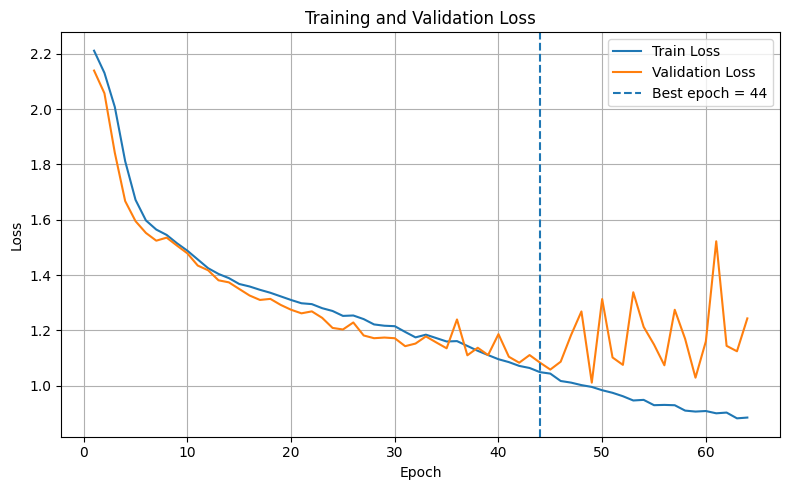

In [269]:
# ============================================================
# Step 12: Training curves
# ============================================================

plt.figure(figsize=(8, 5))

plt.plot(
    transformer_history["epoch"],
    transformer_history["train_loss"],
    label="Train Loss"
)

plt.plot(
    transformer_history["epoch"],
    transformer_history["val_loss"],
    label="Validation Loss"
)

plt.axvline(
    best_epoch,
    linestyle="--",
    label=f"Best epoch = {best_epoch}"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

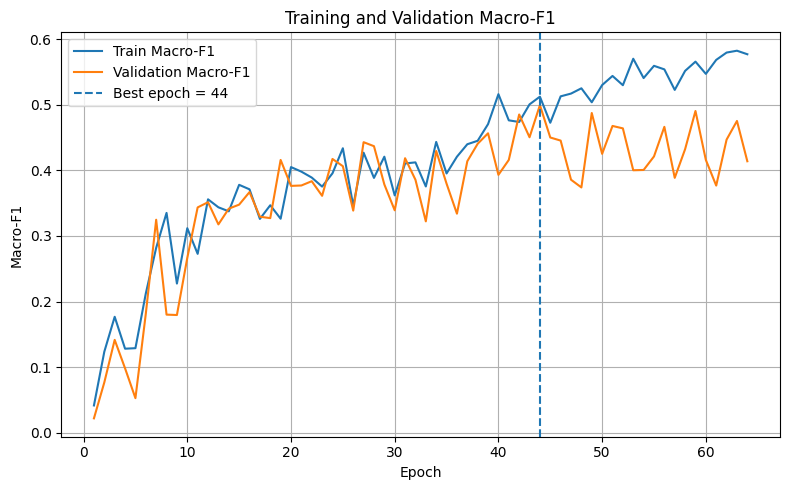

In [270]:
plt.figure(figsize=(8, 5))

plt.plot(
    transformer_history["epoch"],
    transformer_history["train_macro_f1"],
    label="Train Macro-F1"
)

plt.plot(
    transformer_history["epoch"],
    transformer_history["val_macro_f1"],
    label="Validation Macro-F1"
)

plt.axvline(
    best_epoch,
    linestyle="--",
    label=f"Best epoch = {best_epoch}"
)

plt.xlabel("Epoch")
plt.ylabel("Macro-F1")
plt.title("Training and Validation Macro-F1")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()